# Team B Skill Taxonomy — Data Exploration

This notebook evaluates the quality and coverage of the USAJOBS pilot corpus and the preliminary ESCO skill matches.

## Objectives

- Summarize the job-posting corpus.
- Measure missing values and duplicate records.
- Analyze job titles, organizations, locations and posting lengths.
- Check the language of posting text.
- Evaluate the preliminary ESCO matching results.
- Document limitations and recommended next steps.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from langdetect import DetectorFactory, LangDetectException, detect

DetectorFactory.seed = 0

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

POSTINGS_FILE = PROJECT_ROOT / "data/processed/usajobs_postings.csv"
MATCHES_FILE = PROJECT_ROOT / "data/processed/usajobs_esco_matches.csv"
ESCO_FILE = PROJECT_ROOT / "data/reference/esco_skills_en.csv"

print("Project root:", PROJECT_ROOT)

Project root: /Users/lochan/Documents/taxonomy-skill-project


In [2]:
for file_path in [POSTINGS_FILE, MATCHES_FILE, ESCO_FILE]:
    if not file_path.exists():
        raise FileNotFoundError(f"Missing file: {file_path}")

postings = pd.read_csv(POSTINGS_FILE)
matches = pd.read_csv(MATCHES_FILE)
esco = pd.read_csv(ESCO_FILE)

print("Postings shape:", postings.shape)
print("Matches shape:", matches.shape)
print("ESCO shape:", esco.shape)

Postings shape: (25, 16)
Matches shape: (184, 8)
ESCO shape: (14579, 9)


## 1. Dataset Overview

In [3]:
postings["posted_date"] = pd.to_datetime(
    postings["posted_date"],
    errors="coerce",
)

postings["closing_date"] = pd.to_datetime(
    postings["closing_date"],
    errors="coerce",
)

overview = pd.DataFrame(
    {
        "Metric": [
            "Total postings",
            "Unique posting IDs",
            "Unique job titles",
            "Unique organizations",
            "Unique locations",
            "Earliest posted date",
            "Latest posted date",
        ],
        "Value": [
            len(postings),
            postings["posting_id"].nunique(),
            postings["title"].nunique(),
            postings["organization"].nunique(),
            postings["location"].nunique(),
            postings["posted_date"].min().date(),
            postings["posted_date"].max().date(),
        ],
    }
)

overview

,Metric,Value
0,Total postings,25
1,Unique posting IDs,25
2,Unique job titles,22
3,Unique organizations,18
4,Unique locations,17
5,Earliest posted date,2026-04-14
6,Latest posted date,2026-09-24


## 2. Data Quality

In [4]:
quality_report = pd.DataFrame(
    {
        "Check": [
            "Duplicate posting IDs",
            "Duplicate raw text",
            "Empty raw text",
            "Empty duties text",
            "Empty qualifications text",
            "Missing organization",
            "Missing location",
            "Invalid posted date",
            "Invalid closing date",
        ],
        "Count": [
            postings.duplicated(subset=["posting_id"]).sum(),
            postings.duplicated(subset=["raw_text"]).sum(),
            postings["raw_text"].fillna("").str.strip().eq("").sum(),
            postings["duties_text"].fillna("").str.strip().eq("").sum(),
            postings["qualifications_text"].fillna("").str.strip().eq("").sum(),
            postings["organization"].isna().sum(),
            postings["location"].isna().sum(),
            postings["posted_date"].isna().sum(),
            postings["closing_date"].isna().sum(),
        ],
    }
)

quality_report

,Check,Count
0,Duplicate posting IDs,0
1,Duplicate raw text,0
2,Empty raw text,0
3,Empty duties text,0
4,Empty qualifications text,0
5,Missing organization,0
6,Missing location,0
7,Invalid posted date,0
8,Invalid closing date,0


## 3. Posting Coverage

USAJOBS does not provide standardized industry or seniority fields in this pilot. Organization and occupational category are used as available coverage indicators.

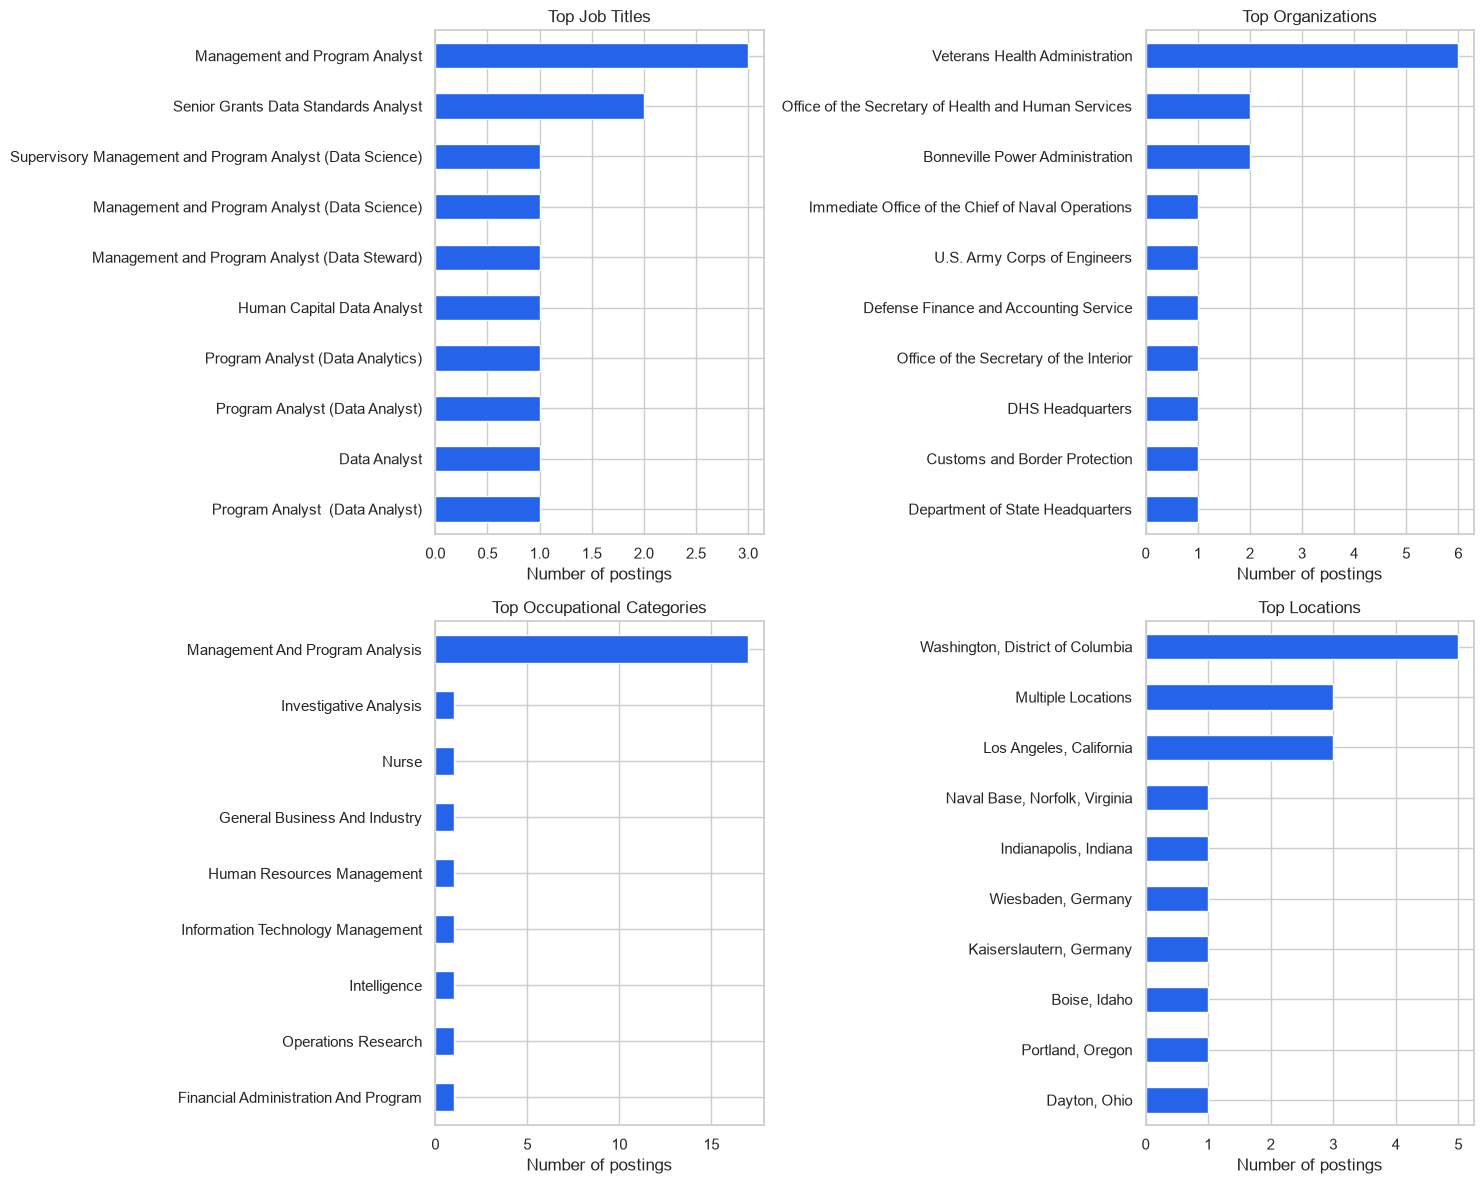

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

plots = [
    ("title", "Top Job Titles"),
    ("organization", "Top Organizations"),
    ("category", "Top Occupational Categories"),
    ("location", "Top Locations"),
]

for axis, (column, title) in zip(axes.flatten(), plots):
    counts = postings[column].value_counts().head(10).sort_values()

    counts.plot(
        kind="barh",
        ax=axis,
        color="#2563EB",
    )

    axis.set_title(title)
    axis.set_xlabel("Number of postings")
    axis.set_ylabel("")

plt.tight_layout()
plt.show()

## 4. Posting Length

,job_summary_word_count,duties_text_word_count,qualifications_text_word_count,raw_text_word_count
count,25.0,25.0,25.0,25.0
mean,49.3,240.7,477.5,1299.5
std,16.2,143.8,265.2,476.7
min,15.0,62.0,136.0,547.0
25%,43.0,129.0,236.0,1121.0
50%,53.0,210.0,442.0,1228.0
75%,63.0,306.0,644.0,1628.0
max,71.0,529.0,1135.0,2313.0


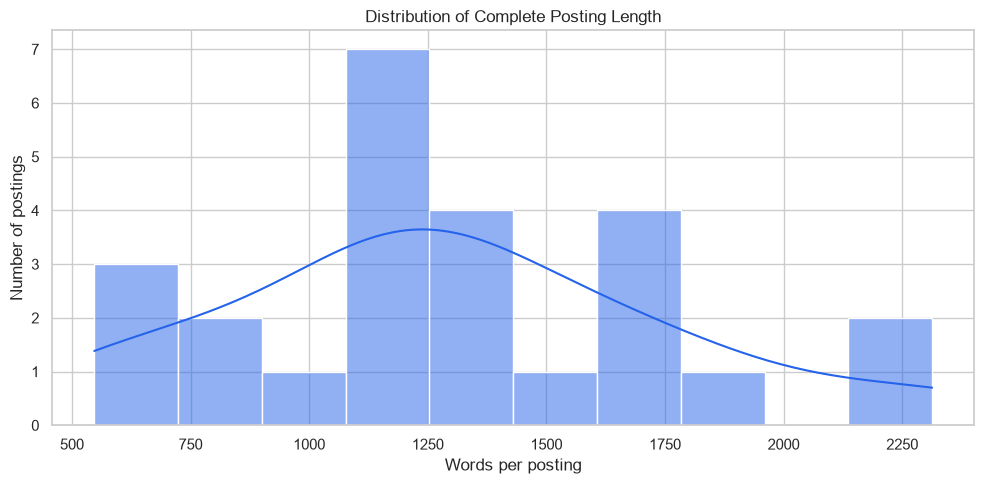

In [6]:
text_columns = [
    "job_summary",
    "duties_text",
    "qualifications_text",
    "raw_text",
]

for column in text_columns:
    postings[f"{column}_word_count"] = (
        postings[column]
        .fillna("")
        .str.split()
        .str.len()
    )

length_summary = (
    postings[
        [f"{column}_word_count" for column in text_columns]
    ]
    .describe()
    .round(1)
)

display(length_summary)

plt.figure(figsize=(10, 5))

sns.histplot(
    data=postings,
    x="raw_text_word_count",
    bins=10,
    kde=True,
    color="#2563EB",
)

plt.title("Distribution of Complete Posting Length")
plt.xlabel("Words per posting")
plt.ylabel("Number of postings")
plt.tight_layout()
plt.show()

## 5. Language Distribution

,Language,Postings
0,en,25


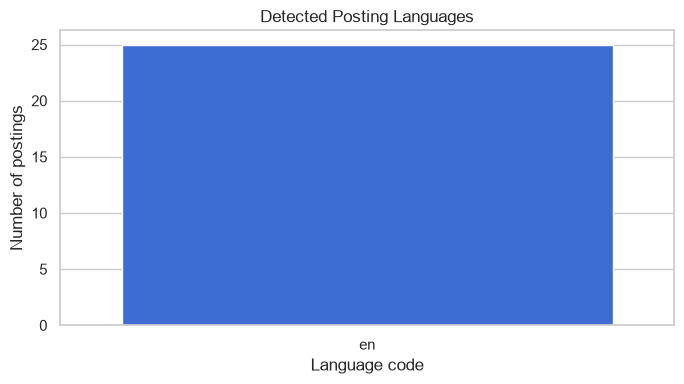

In [7]:
def detect_language(text):
    cleaned_text = str(text).strip()

    if len(cleaned_text) < 20:
        return "unknown"

    try:
        return detect(cleaned_text)
    except LangDetectException:
        return "unknown"


postings["detected_language"] = postings["raw_text"].apply(
    detect_language
)

language_counts = (
    postings["detected_language"]
    .value_counts()
    .rename_axis("Language")
    .reset_index(name="Postings")
)

display(language_counts)

plt.figure(figsize=(7, 4))

sns.barplot(
    data=language_counts,
    x="Language",
    y="Postings",
    color="#2563EB",
)

plt.title("Detected Posting Languages")
plt.xlabel("Language code")
plt.ylabel("Number of postings")
plt.tight_layout()
plt.show()

## 6. Preliminary ESCO Matching

These matches were produced using exact preferred-label matching. They are candidate matches and have not yet been manually validated.

,match_count
count,25.0
mean,7.4
std,3.3
min,2.0
25%,5.0
50%,7.0
75%,10.0
max,13.0


,Posting count
preferred_label,
skills,21
knowledge,21
personnel management,14
education,11
services,9
data analytics,7
communicating,6
health,6
plan,6


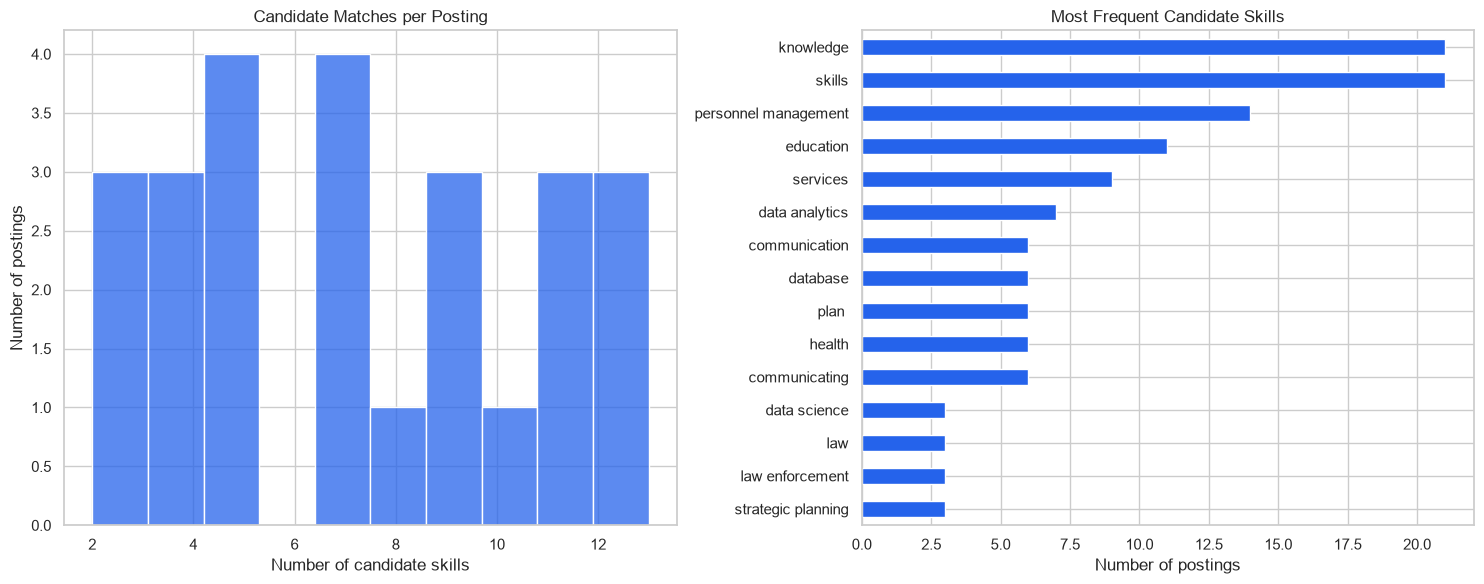

In [8]:
matches_per_posting = (
    matches.groupby("posting_id")
    .size()
    .rename("match_count")
)

match_summary = matches_per_posting.describe().round(1)

top_skills = (
    matches["preferred_label"]
    .value_counts()
    .head(15)
    .sort_values()
)

display(match_summary.to_frame())
display(
    top_skills.sort_values(ascending=False)
    .rename("Posting count")
    .to_frame()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(
    matches_per_posting,
    bins=10,
    ax=axes[0],
    color="#2563EB",
)

axes[0].set_title("Candidate Matches per Posting")
axes[0].set_xlabel("Number of candidate skills")
axes[0].set_ylabel("Number of postings")

top_skills.plot(
    kind="barh",
    ax=axes[1],
    color="#2563EB",
)

axes[1].set_title("Most Frequent Candidate Skills")
axes[1].set_xlabel("Number of postings")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 7. Baseline Match Limitations

Exact matching can detect valid skills, but it also returns broad words that are not useful as job-specific skills. The following check flags several known generic labels for manual review.

In [9]:
generic_labels = {
    "communication",
    "communicating",
    "education",
    "health",
    "knowledge",
    "plan",
    "services",
    "skills",
}

generic_matches = matches[
    matches["preferred_label"]
    .str.lower()
    .isin(generic_labels)
].copy()

generic_summary = (
    generic_matches["preferred_label"]
    .value_counts()
    .rename_axis("Generic label")
    .reset_index(name="Matches")
)

generic_rate = len(generic_matches) / len(matches)

display(generic_summary)

print("Generic candidate matches:", len(generic_matches))
print("Total candidate matches:", len(matches))
print(f"Generic candidate rate: {generic_rate:.1%}")

,Generic label,Matches
0,skills,21
1,knowledge,21
2,education,11
3,services,9
4,communicating,6
5,health,6
6,communication,6


Generic candidate matches: 80
Total candidate matches: 184
Generic candidate rate: 43.5%


## 8. ESCO Reference Coverage

,Metric,Value
0,Total ESCO concepts,14579
1,Unique skill URIs,14579
2,Missing preferred labels,0
3,Concepts with descriptions,14446
4,Concepts with parent links,4977
5,Unique skill types,2
6,Unique reuse levels,4


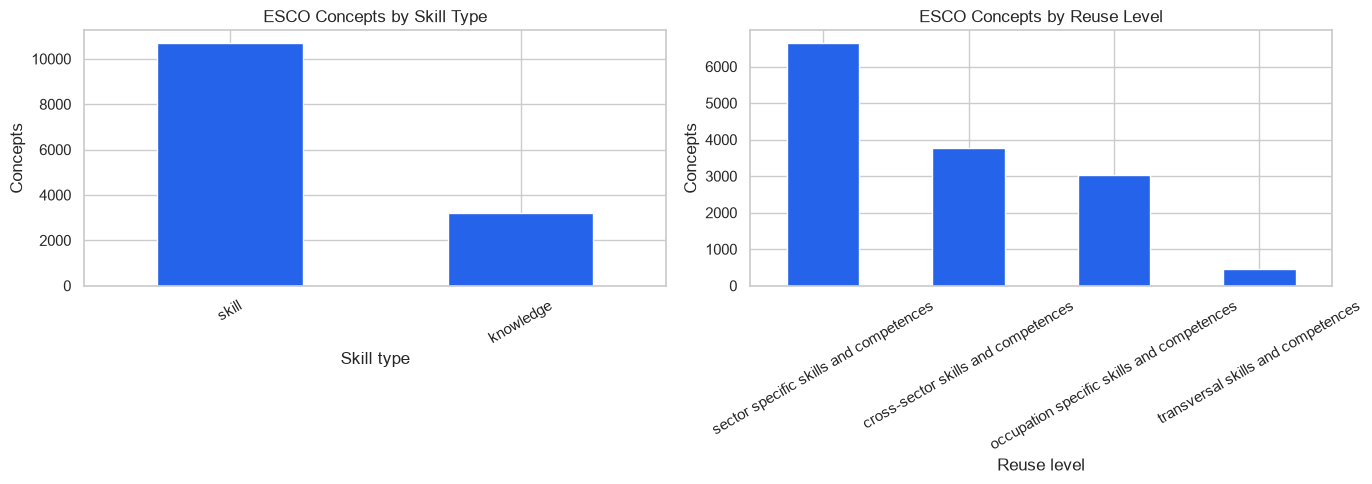

In [10]:
esco_quality = pd.DataFrame(
    {
        "Metric": [
            "Total ESCO concepts",
            "Unique skill URIs",
            "Missing preferred labels",
            "Concepts with descriptions",
            "Concepts with parent links",
            "Unique skill types",
            "Unique reuse levels",
        ],
        "Value": [
            len(esco),
            esco["skill_uri"].nunique(),
            esco["preferred_label"].isna().sum(),
            esco["description"].notna().sum(),
            esco["broader_skill_uris"].notna().sum(),
            esco["skill_type"].nunique(),
            esco["reuse_level"].nunique(),
        ],
    }
)

display(esco_quality)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

esco["skill_type"].value_counts().plot(
    kind="bar",
    ax=axes[0],
    color="#2563EB",
)

axes[0].set_title("ESCO Concepts by Skill Type")
axes[0].set_xlabel("Skill type")
axes[0].set_ylabel("Concepts")
axes[0].tick_params(axis="x", rotation=30)

esco["reuse_level"].value_counts().plot(
    kind="bar",
    ax=axes[1],
    color="#2563EB",
)

axes[1].set_title("ESCO Concepts by Reuse Level")
axes[1].set_xlabel("Reuse level")
axes[1].set_ylabel("Concepts")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 9. Key Findings and Limitations

### Findings

- The pilot contains 25 postings covering 22 job titles, 18 organizations and 17 locations.
- No duplicate posting IDs, duplicate posting text, empty required text or invalid dates were found.
- All 25 postings were detected as English.
- Complete posting length ranges from 547 to 2,313 words, with a median of approximately 1,228 words.
- The corpus is concentrated in U.S. federal organizations and management/program-analysis occupations.
- Exact ESCO matching produced 184 candidate matches across all 25 postings, averaging 7.4 matches per posting.
- 80 of the 184 matches (43.5%) use clearly generic labels such as "skills," "knowledge," "education" and "services."
- ESCO contains 14,579 concepts, including 14,446 descriptions and 4,977 parent-skill links.

### Limitations

- The corpus is too small for building a representative skill taxonomy.
- The postings cover federal employment and do not represent the broader labor market.
- Standardized industry and seniority fields are not available in the current pilot.
- Exact preferred-label matching produces substantial generic and ambiguous matches.
- The 184 matches are baseline candidates, not validated skill statements.
- Extraction precision and recall cannot be measured until a manually labelled sample is created.

### Recommended Next Actions

1. Expand the corpus to at least 100 postings across several occupations.
2. Extract one atomic skill statement per capability mentioned.
3. Create a manually labelled evaluation set.
4. Measure extraction precision, recall and F1.
5. Map extracted statements to ESCO using semantic similarity.
6. Use ESCO parent relationships to help construct the final hierarchy.